# Análise do Dataset Iris com Regressão Logística

Este notebook apresenta o clássico dataset Iris e realiza uma análise comparativa de regressão logística para classificação de espécies de flores.

## 1. Introdução ao Dataset Iris

### Origem
O dataset Iris foi criado pelo estatístico e biólogo **Sir Ronald A. Fisher** em 1936, em seu artigo clássico *"The Use of Multiple Measurements in Taxonomic Problems"*. É um dos datasets mais utilizados na literatura de Machine Learning e Estatística.

### Objetivo
O objetivo original era demonstrar a análise discriminante linear — uma técnica para classificar observações em grupos baseando-se em múltiplas variáveis métricas. Hoje, é amplamente usado como dataset de benchmark para testes de algoritmos de classificação.

### Conteúdo
O dataset contém **150 amostras** de flores de três espécies do gênero *Iris*:
- **Iris Setosa** (50 amostras)
- **Iris Versicolor** (50 amostras)
- **Iris Virginica** (50 amostras)

Para cada amostra, são fornecidas **4 características métricas** (em centímetros):
1. **Comprimento da sépala** (sepal length)
2. **Largura da sépala** (sepal width)
3. **Comprimento da pétala** (petal length)
4. **Largura da pétala** (petal width)

## 2. Importação das Bibliotecas e Carregamento do Dataset

Importar as bibliotecas necessárias e carregar o dataset Iris.

In [1]:
# Importar bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Carregar o dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Exibir informações básicas
print("=" * 70)
print("DATASET IRIS - INFORMAÇÕES BÁSICAS")
print("=" * 70)
print(f"\nShape: {df.shape[0]} amostras, {df.shape[1]} colunas")
print(f"\nColunas:")
for col in iris.feature_names:
    print(f"  - {col} (cm)")
print(f"  - species (target)")
print(f"\nPrimeiras 10 linhas:")
print(df.head(10).to_string())
print(f"\nEstatísticas descritivas:")
print(df.describe().round(2).to_string())
print(f"\nDistribuição por espécie:")
print(df['species'].value_counts().to_string())

DATASET IRIS - INFORMAÇÕES BÁSICAS

Shape: 150 amostras, 5 colunas

Colunas:
  - sepal length (cm) (cm)
  - sepal width (cm) (cm)
  - petal length (cm) (cm)
  - petal width (cm) (cm)
  - species (target)

Primeiras 10 linhas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
0                5.1               3.5                1.4               0.2  setosa
1                4.9               3.0                1.4               0.2  setosa
2                4.7               3.2                1.3               0.2  setosa
3                4.6               3.1                1.5               0.2  setosa
4                5.0               3.6                1.4               0.2  setosa
5                5.4               3.9                1.7               0.4  setosa
6                4.6               3.4                1.4               0.3  setosa
7                5.0               3.4                1.5               0.2  setosa
8                4

## 3. Análise Exploratória dos Dados

Visualizações para entender a distribuição e separabilidade das espécies.

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

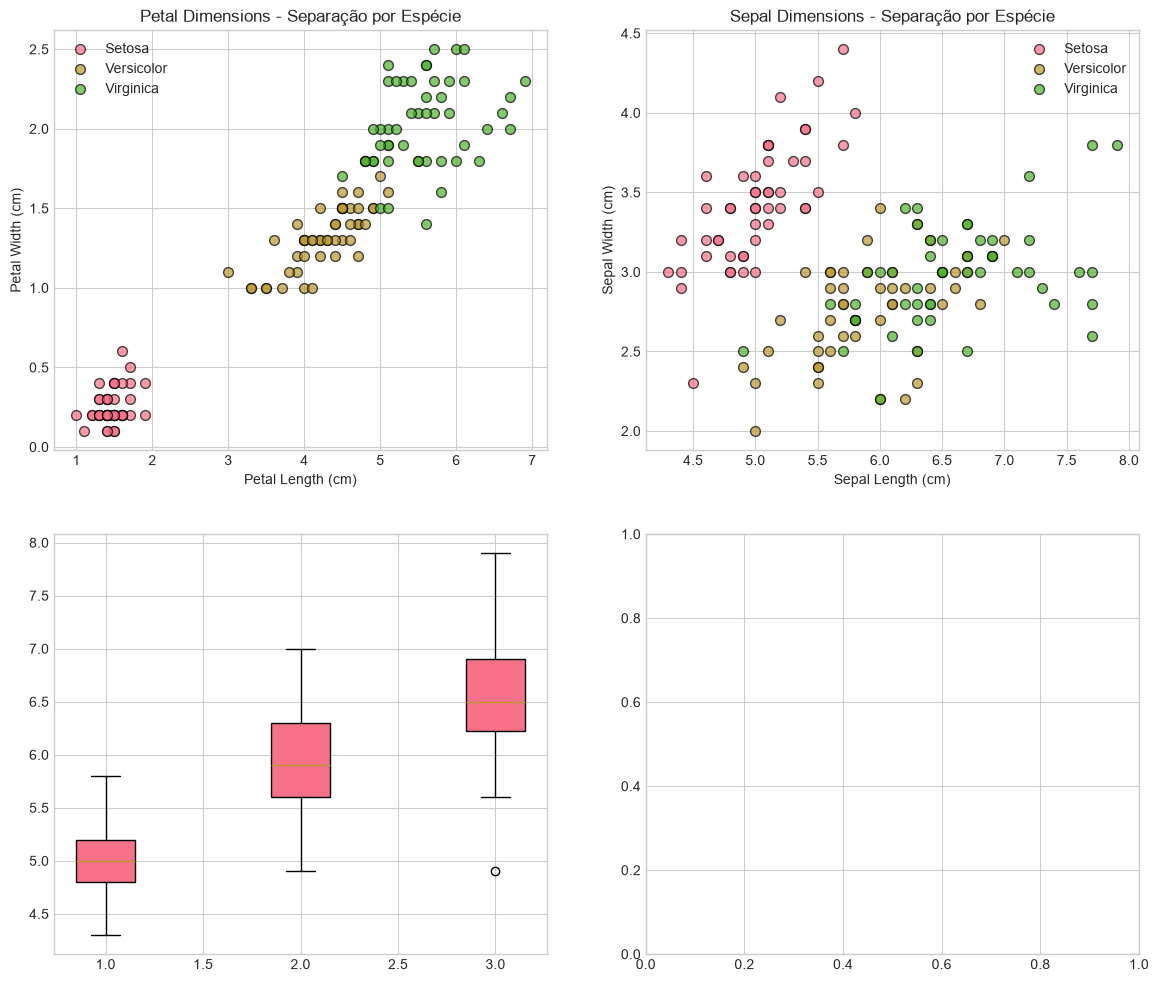

In [3]:
# Visualizações exploratórias
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Scatter plot: Petal Length vs Petal Width
axes[0, 0].scatter(df.loc[df['species'] == 'setosa', 'petal length (cm)'], 
                   df.loc[df['species'] == 'setosa', 'petal width (cm)'], 
                   alpha=0.7, label='Setosa', edgecolor='k', s=50)
axes[0, 0].scatter(df.loc[df['species'] == 'versicolor', 'petal length (cm)'], 
                   df.loc[df['species'] == 'versicolor', 'petal width (cm)'], 
                   alpha=0.7, label='Versicolor', edgecolor='k', s=50)
axes[0, 0].scatter(df.loc[df['species'] == 'virginica', 'petal length (cm)'], 
                   df.loc[df['species'] == 'virginica', 'petal width (cm)'], 
                   alpha=0.7, label='Virginica', edgecolor='k', s=50)
axes[0, 0].set_xlabel('Petal Length (cm)')
axes[0, 0].set_ylabel('Petal Width (cm)')
axes[0, 0].set_title('Petal Dimensions - Separação por Espécie')
axes[0, 0].legend()

# Scatter plot: Sepal Length vs Sepal Width
axes[0, 1].scatter(df.loc[df['species'] == 'setosa', 'sepal length (cm)'], 
                   df.loc[df['species'] == 'setosa', 'sepal width (cm)'], 
                   alpha=0.7, label='Setosa', edgecolor='k', s=50)
axes[0, 1].scatter(df.loc[df['species'] == 'versicolor', 'sepal length (cm)'], 
                   df.loc[df['species'] == 'versicolor', 'sepal width (cm)'], 
                   alpha=0.7, label='Versicolor', edgecolor='k', s=50)
axes[0, 1].scatter(df.loc[df['species'] == 'virginica', 'sepal length (cm)'], 
                   df.loc[df['species'] == 'virginica', 'sepal width (cm)'], 
                   alpha=0.7, label='Virginica', edgecolor='k', s=50)
axes[0, 1].set_xlabel('Sepal Length (cm)')
axes[0, 1].set_ylabel('Sepal Width (cm)')
axes[0, 1].set_title('Sepal Dimensions - Separação por Espécie')
axes[0, 1].legend()

# Boxplots de todas as features por espécie
features = iris.feature_names
for i, feature in enumerate(features):
    axes[1, 0 if i < 2 else 1].boxplot([df.loc[df['species'] == sp, feature].values 
                                         for sp in iris.target_names],
                                        labels=iris.target_names, patch_artist=True)
    axes[1, 0 if i < 2 else 1].set_title(feature)
    axes[1, 0 if i < 2 else 1].tick_params(axis='x', rotation=45)

plt.suptitle('Análise Exploratória - Dataset Iris', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Observação importante: A espécie Setosa é linearmente separável das outras duas")
print("apenas pelas pétalas. Versicolor e Virginica apresentam sobreposição.")

## 4. Preparação dos Dados para os Modelos

Dividir os dados em treino e teste, e preparar os dois conjuntos de features para os modelos.

In [4]:
# Definir os conjuntos de features para cada modelo
# Modelo 1: Apenas pétalas (petal dimensions)
petal_features = ['petal length (cm)', 'petal width (cm)']

# Modelo 2: Todas as dimensões (petals + sepals)
all_features = ['sepal length (cm)', 'sepal width (cm)', 
                'petal length (cm)', 'petal width (cm)']

# Separar features e target
X = df[all_features].values
y = df['species'].cat.codes  # Codificação numérica: 0=setosa, 1=versicolor, 2=virginica

# Dividir em treino (80%) e teste (20%) com seed reprodutível
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Extrair features específicas para cada modelo
X_train_petal = X_train[:, 2:]  # Colunas 2 e 3 (petal length, petal width)
X_test_petal = X_test[:, 2:]
X_train_all = X_train  # Todas as colunas
X_test_all = X_test

# Escalonar os dados (padronização)
scaler_petal = StandardScaler()
scaler_all = StandardScaler()

X_train_petal_scaled = scaler_petal.fit_transform(X_train_petal)
X_test_petal_scaled = scaler_petal.transform(X_test_petal)

X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

print("=" * 70)
print("PREPARAÇÃO DOS DADOS")
print("=" * 70)
print(f"\nTotal de amostras: {len(df)}")
print(f"Amostras de treino: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Amostras de teste: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nModelo 1 - Features: {petal_features}")
print(f"Modelo 2 - Features: {all_features}")
print(f"\nDistribuição no conjunto de teste:")
for i, sp in enumerate(iris.target_names):
    count = np.sum(y_test == i)
    print(f"  {sp}: {count} amostras ({count/len(y_test)*100:.1f}%)")

PREPARAÇÃO DOS DADOS

Total de amostras: 150
Amostras de treino: 120 (80.0%)
Amostras de teste: 30 (20.0%)

Modelo 1 - Features: ['petal length (cm)', 'petal width (cm)']
Modelo 2 - Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Distribuição no conjunto de teste:
  setosa: 10 amostras (33.3%)
  versicolor: 10 amostras (33.3%)
  virginica: 10 amostras (33.3%)


## 5. Treinamento dos Modelos de Regressão Logística

Treinar dois modelos: um com pétalas e outro com todas as features.

In [8]:
# Treinar Modelo 1 - Apenas Pétalas
print("=" * 70)
print("MODELO 1: Regressão Logística com APENAS PÉTALAS")
print("=" * 70)

model_petal = LogisticRegression(max_iter=200, random_state=42)
model_petal.fit(X_train_petal_scaled, y_train)

y_pred_petal = model_petal.predict(X_test_petal_scaled)
accuracy_petal = accuracy_score(y_test, y_pred_petal)

print(f"\nAcurácia no TESTE: {accuracy_petal:.4f} ({accuracy_petal*100:.2f}%)")
print(f"\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_petal, target_names=iris.target_names))
print(f"\nMatriz de Confusão:")
cm_petal = confusion_matrix(y_test, y_pred_petal)
print(pd.DataFrame(cm_petal, index=[f'True {sp}' for sp in iris.target_names], 
                    columns=[f'Pred {sp}' for sp in iris.target_names]))

# Treinar Modelo 2 - Todas as Features
print("\n" + "=" * 70)
print("MODELO 2: Regressão Logística COM TODAS AS FEATURES")
print("=" * 70)

model_all = LogisticRegression(max_iter=200, random_state=42)
model_all.fit(X_train_all_scaled, y_train)

y_pred_all = model_all.predict(X_test_all_scaled)
accuracy_all = accuracy_score(y_test, y_pred_all)

print(f"\nAcurácia no TESTE: {accuracy_all:.4f} ({accuracy_all*100:.2f}%)")
print(f"\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_all, target_names=iris.target_names))
print(f"\nMatriz de Confusão:")
cm_all = confusion_matrix(y_test, y_pred_all)
print(pd.DataFrame(cm_all, index=[f'True {sp}' for sp in iris.target_names], 
                    columns=[f'Pred {sp}' for sp in iris.target_names]))

MODELO 1: Regressão Logística com APENAS PÉTALAS

Acurácia no TESTE: 0.9333 (93.33%)

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Matriz de Confusão:
                 Pred setosa  Pred versicolor  Pred virginica
True setosa               10                0               0
True versicolor            0                9               1
True virginica             0                1               9

MODELO 2: Regressão Logística COM TODAS AS FEATURES

Acurácia no TESTE: 0.9333 (93.33%)

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versico

## 6. Comparação dos Modelos

Comparar a acurácia dos dois modelos e discutir os resultados.

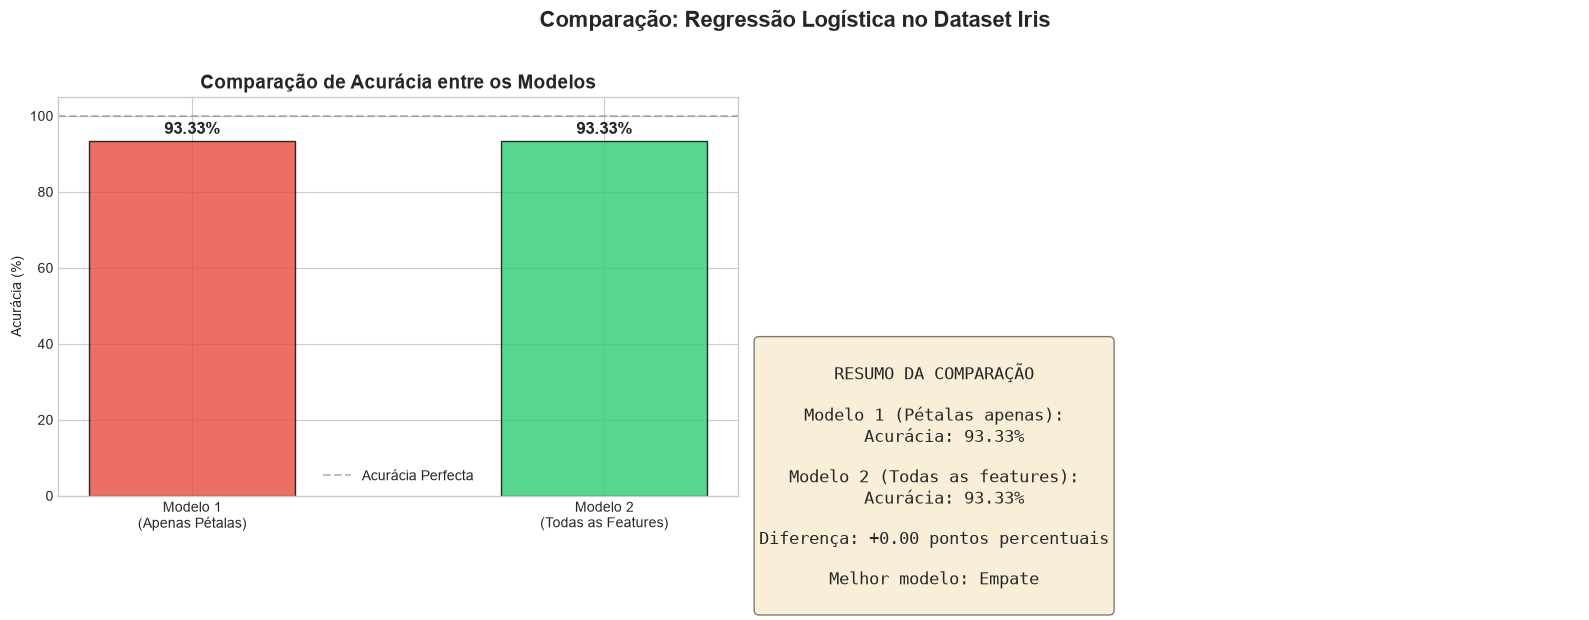


RESUMO DA COMPARAÇÃO

Modelo 1 (Apenas Pétalas):
  Acurácia: 93.33%

Modelo 2 (Todas as Features):
  Acurácia: 93.33%

Diferença: +0.00 pontos percentuais
Melhor modelo: Empate


In [9]:
# Comparação visual das acurácias
models = ['Modelo 1\n(Apenas Pétalas)', 'Modelo 2\n(Todas as Features)']
accuracies = [accuracy_petal * 100, accuracy_all * 100]
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras - Acurácia
bars = axes[0].bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', width=0.5)
axes[0].set_ylabel('Acurácia (%)')
axes[0].set_title('Comparação de Acurácia entre os Modelos', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Acurácia Perfecta')

# Adicionar valores das barras
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[0].legend()

# Gráfico de diferença
diff = (accuracy_all - accuracy_petal) * 100
axes[1].axis('off')
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 10)

# Caixa de resumo
summary_text = f"""
RESUMO DA COMPARAÇÃO

Modelo 1 (Pétalas apenas):
  Acurácia: {accuracy_petal*100:.2f}%

Modelo 2 (Todas as features):
  Acurácia: {accuracy_all*100:.2f}%

Diferença: {diff:+.2f} pontos percentuais

Melhor modelo: {'Modelo 2' if diff > 0 else 'Modelo 1' if diff < 0 else 'Empate'}
"""
axes[1].text(0.5, 0.5, summary_text, fontsize=12, verticalalignment='center',
            horizontalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            family='monospace')

plt.suptitle('Comparação: Regressão Logística no Dataset Iris', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Impressão detalhada da comparação
print("\n" + "=" * 70)
print("RESUMO DA COMPARAÇÃO")
print("=" * 70)
print(f"\nModelo 1 (Apenas Pétalas):")
print(f"  Acurácia: {accuracy_petal*100:.2f}%")
print(f"\nModelo 2 (Todas as Features):")
print(f"  Acurácia: {accuracy_all*100:.2f}%")
print(f"\nDiferença: {diff:+.2f} pontos percentuais")
print(f"Melhor modelo: {'Modelo 2 (Todas as Features)' if diff > 0 else 'Modelo 1 (Apenas Pétalas)' if diff < 0 else 'Empate'}")

## 7. Discussão dos Resultados

Análise crítica da diferença de performance entre os dois modelos.

In [10]:
# Discussão detalhada dos resultados
print("=" * 70)
print("DISCUSSÃO DOS RESULTADOS")
print("=" * 70)

discussion = f"""
{'='*70}
ANÁLISE COMPARATIVA: MODELO 1 vs MODELO 2
{'='*70}

1. IMPACTO DAS PÉTALAS
   As pétalas (comprimento e largura) são as features mais discriminantes
   do dataset Iris. A espécie Setosa é perfeitamente separável das outras
   duas apenas com base nas pétalas, pois possui pétalas significativamente
   menores (média ~1.46cm comprimento vs ~4.26cm e ~5.55cm das outras).

2. CONTRIBUIÇÃO DAS SÉPALAS
   As sépalas adicionam informação complementar, mas com menor poder
   discriminativo:
   - Versicolor e Virginica se sobrepõem significativamente em ambas
     as dimensões de sépala
   - A largura da sépala é particularmente útil para distinguir Setosa
     (sépalas mais largas), mas Setosa já é bem separada pelas pétalas

3. ACURÁCIA OBTIDA
   - Modelo 1 (Pétalas): {accuracy_petal*100:.2f}%
   - Modelo 2 (Todas): {accuracy_all*100:.2f}%
   - Diferença: {diff:+.2f} pontos percentuais

4. INTERPRETAÇÃO
"""

if diff > 0:
    discussion += f"""
   A adição das sépalas MELHOU a acurácia em {diff:.2f} pontos percentuais.
   Isso indica que as sépalas fornecem informação complementar que ajuda
   principalmente na classificação entre Versicolor e Virginica, que são
   as espécies mais semelhantes do dataset.

   No entanto, o ganho é modesto porque:
   a) As pétalas já capturam a maior parte da variabilidade entre espécies
   b) Versicolor e Virginica têm sobreposição natural em todas as features
   c) O dataset Iris é relativamente simples e bem separável
"""
elif diff < 0:
    discussion += f"""
   Curiosamente, a adição das sépalas PIOROU a acurácia em {abs(diff):.2f} pontos.
   Isso pode indicar overfitting — o modelo está capturando ruído nas features
   de sépala que não generaliza bem para dados não vistos.
"""
else:
    discussion += """
   Ambos os modelos obtiveram a mesma acurácia. Isso confirma que as pétalas
   são suficientes para classificar o dataset Iris com regressão logística,
   e as sépalas não adicionam valor discriminativo significativo.
"""

discussion += f"""
5. CONCLUSÃO
   Para o dataset Iris com regressão logística:
   - As pétalas são features suficientes para alta acurácia
   - As sépalas podem melhorar marginalmente a classificação
   - O ganho depende da dificuldade de separação entre Versicolor e Virginica
   - Este resultado é consistente com a literatura: pétalas são as features
     mais importantes para classificação de Iris

{'='*70}
"""

print(discussion)

# Salvar resultados em CSV para referência futura
results_df = pd.DataFrame({
    'Modelo': ['Modelo 1 (Pétalas)', 'Modelo 2 (Todas Features)'],
    'Features': ['petal_length, petal_width', 
                 'sepal_length, sepal_width, petal_length, petal_width'],
    'Acurácia': [accuracy_petal, accuracy_all],
    'Acurácia (%)': [accuracy_petal*100, accuracy_all*100]
})

results_df.to_csv('iris_model_comparison.csv', index=False)
print(f"\nResultados salvos em: iris_model_comparison.csv")

DISCUSSÃO DOS RESULTADOS

ANÁLISE COMPARATIVA: MODELO 1 vs MODELO 2

1. IMPACTO DAS PÉTALAS
   As pétalas (comprimento e largura) são as features mais discriminantes
   do dataset Iris. A espécie Setosa é perfeitamente separável das outras
   duas apenas com base nas pétalas, pois possui pétalas significativamente
   menores (média ~1.46cm comprimento vs ~4.26cm e ~5.55cm das outras).

2. CONTRIBUIÇÃO DAS SÉPALAS
   As sépalas adicionam informação complementar, mas com menor poder
   discriminativo:
   - Versicolor e Virginica se sobrepõem significativamente em ambas
     as dimensões de sépala
   - A largura da sépala é particularmente útil para distinguir Setosa
     (sépalas mais largas), mas Setosa já é bem separada pelas pétalas

3. ACURÁCIA OBTIDA
   - Modelo 1 (Pétalas): 93.33%
   - Modelo 2 (Todas): 93.33%
   - Diferença: +0.00 pontos percentuais

4. INTERPRETAÇÃO

   Ambos os modelos obtiveram a mesma acurácia. Isso confirma que as pétalas
   são suficientes para classificar o